# EDA - Smart LMS Dashboard (FT-04)



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

In [3]:
# read log data 
logs = pd.read_excel('ICT001 S1 2025 Logs RELEASED V1.0.xlsx')


In [4]:
# read result data 
results = pd.read_excel('ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx')

In [5]:
# count how many times each user appears in logs
if 'User ID' in logs.columns:
    user_counts = logs['User ID'].value_counts()
elif 'Username' in logs.columns:
    user_counts = logs['Username'].value_counts()
elif 'User full name' in logs.columns:
    user_counts = logs['User full name'].value_counts()
else:
    user_ids = logs['Description'].str.extract(r"id '(\d+)'", expand=False)
    user_counts = user_ids.value_counts()
print(user_counts)  


# average number of log entries per user
average_logs_per_user = user_counts.mean()
print(f"Average number of log entries per user: {average_logs_per_user:.2f}")

Username
15925004@student.murdoch.edu.au    1294
15925153@student.murdoch.edu.au    1223
15925019@student.murdoch.edu.au    1206
15925125@student.murdoch.edu.au    1203
20220829@murdoch.edu.au            1087
                                   ... 
15925058@student.murdoch.edu.au      12
15925024@student.murdoch.edu.au       8
15925164@student.murdoch.edu.au       7
15925170@student.murdoch.edu.au       7
15925041@student.murdoch.edu.au       2
Name: count, Length: 169, dtype: int64
Average number of log entries per user: 324.33


In [6]:
# count least active student log
if 'User ID' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
elif 'Username' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
elif 'User full name' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
else:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()  
print(f"Least active user: {least_active_user} with {least_active_count} log entries")

Least active user: 15925041@student.murdoch.edu.au with 2 log entries


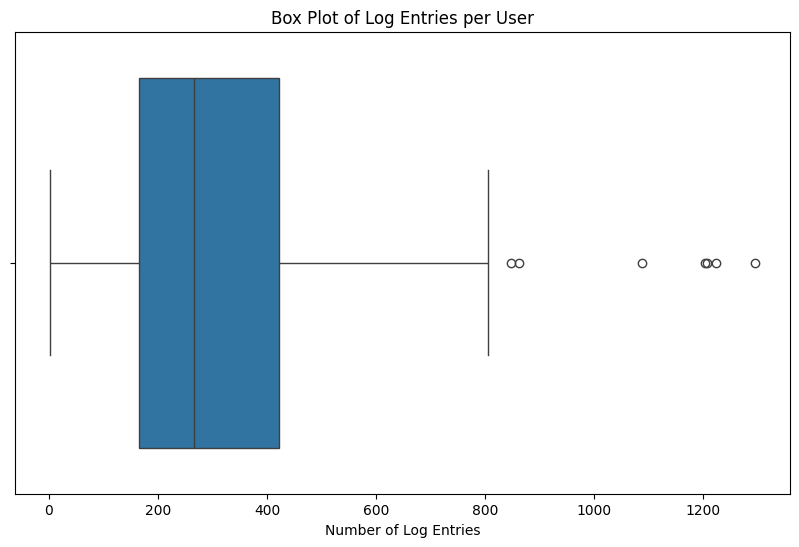

In [7]:
# plot user counts in a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=user_counts)
plt.title('Box Plot of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.show()

## Finding 1: Student Engagement Level 
- The moodle activity log analysis revealed variation in student engagment level throughout S1 2025 semester. 
- A total of 169 students, with an average of approx **424 log entries per student**.  
- the box plot shows that most students recorded between approx 170 and 430 log entries, with a media around 270 log and mean 324.33 per student 
- Some students with high activity levels appearing as outliers beyond upper whisker. 
- the most active students recorded more than 1,000 log entries up to over 1,200, while the least active students recorded 2. 

>>These finding indicate that student engagement is highly uneven across sememster. 

Key Statistics

* Total students: 169
* Average log entries per student: 324.33
* Highest activity: 1,294 log entries
* Lowest activity: 2 log entries
* Several high-activity outliers (> 800 log entries) were identified


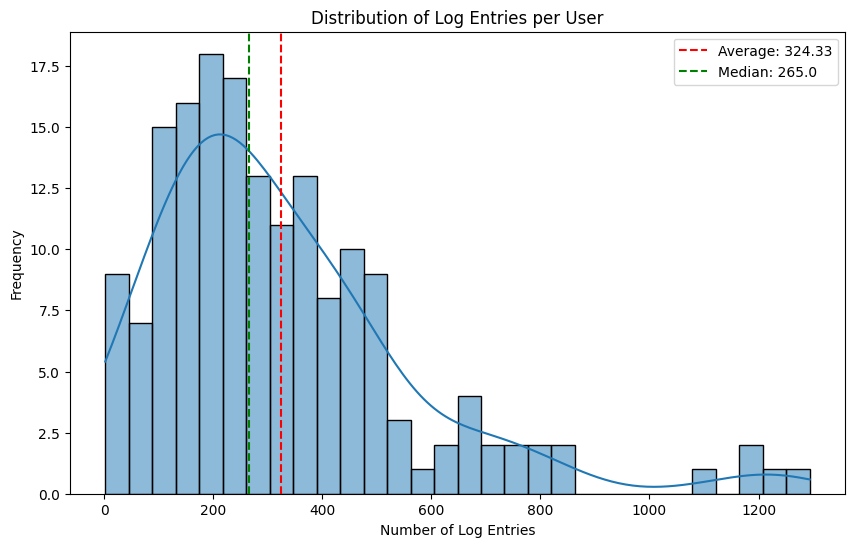

In [8]:
# distribution of log entries per user with average line and median line
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=30, kde=True)        
plt.axvline(average_logs_per_user, color='red', linestyle='--', label=f'Average: {average_logs_per_user:.2f}')
plt.axvline(user_counts.median(), color='green', linestyle='--', label=f'Median: {user_counts.median()}')
plt.title('Distribution of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [9]:
print(user_counts.describe())

count     169.000000
mean      324.331361
std       243.548878
min         2.000000
25%       165.000000
50%       265.000000
75%       421.000000
max      1294.000000
Name: count, dtype: float64


## Finding 2: Student Activity Distribution is Right-Skewed 

The distribution of Moodle log entries per student is right-skewed, indicating that most students generated a moderate number of LMS interactions, while a small number of students are exceptionally active. 

Key observations: 
 * The average number of log entries per student was 324.33
 * Most students recorded between approx 150 and 500 log entries. 
 * the highest concentration of students appears around 200-300 log entries, suggesting this represents the typical engagement level within the term. 
 * A small number of students generated more activity, with several students exceeding 1,000 log entries. 
 * The most active student recorded 1,294 log entries, while the least active students recorded only 2 log entries. 

 The long tail on the right side of the distribution indicates the presence of highly active students who accessed Moodle resources considerably more frequently than the rest of the cohort. These extreme values contribute to the righ-skewed shape and increase the overall average. 

 Interpretation 
 The distribution suggests that student engagement is not evenly distributed across the cohort. While most students demostrated moderated LMS usage, a subset of students exhibit either: 
 * **very highly engagement**, potentially due to frequent access to learning materials, repeated review of resources, or intensive study behavior; or 
 * **Very low engagemen**, which may indicate disengagment and could serve as an early warning sigh for academic risk. 

 

## Relationship between log entries and student results 


In [10]:
results = pd.read_excel(
    "ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx",
    header=2
)


In [13]:
results.Grade.value_counts()

Grade
N     73
P     23
C     19
D     16
S     14
SA    13
HD     9
DX     3
Name: count, dtype: int64

In [14]:
# how many % of students got each grade
grade_counts = results['Grade'].value_counts(normalize=True) * 100
print(f"Percentage of students for each grade:\n{grade_counts}")

Percentage of students for each grade:
Grade
N     42.941176
P     13.529412
C     11.176471
D      9.411765
S      8.235294
SA     7.647059
HD     5.294118
DX     1.764706
Name: proportion, dtype: float64


In [15]:
# Clean Person Id in logs
if 'Username' in logs.columns:
    logs['Person Id'] = (
        logs['Username']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )
    print(logs[['Username', 'Person Id']].head())
else:
    print("Column 'Username' not found in logs.")

# Clean Person Id in results
if 'Person Id' in results.columns:
    results['Person Id'] = (
        results['Person Id']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )
    print(results[['Person Id']].head())
else:
    print("Column 'Person Id' not found in results.")

                          Username Person Id
0          20220829@murdoch.edu.au  20220829
1  15925111@student.murdoch.edu.au  15925111
2  15925111@student.murdoch.edu.au  15925111
3  15925111@student.murdoch.edu.au  15925111
4  15925111@student.murdoch.edu.au  15925111
  Person Id
0  15925001
1  15925002
2  15925003
3  15925004
4  15925005


In [16]:
# Aggregate logs first: one row per student
log_entries = (
    logs
    .dropna(subset=['Person Id'])
    .groupby('Person Id')
    .size()
    .reset_index(name='Log Entries')
)

# Merge with results: one row per student
student_level_df = pd.merge(
    results[['Person Id', 'Grade', 'Mark']],
    log_entries,
    on='Person Id',
    how='left'
)

student_level_df['Log Entries'] = (
    student_level_df['Log Entries']
    .fillna(0)
    .astype(int)
)

# Average log entries by grade
student_level_df.groupby('Grade')['Log Entries'].mean()

Grade
C     298.789474
D     460.250000
DX    447.000000
HD    432.000000
N     226.520548
P     367.000000
S     394.214286
SA    381.461538
Name: Log Entries, dtype: float64

In [17]:
print(len(student_level_df))
print(student_level_df['Person Id'].nunique())

236
170


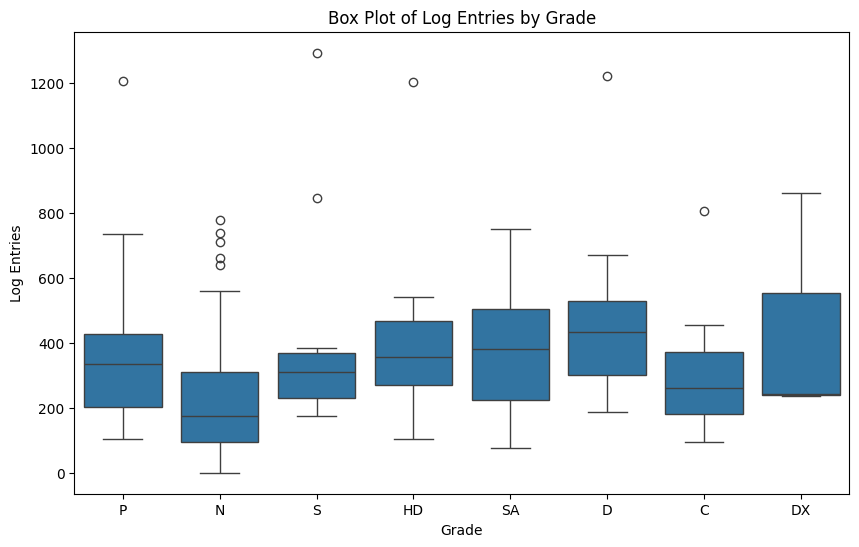

In [18]:
# check corelation between log entries and grades
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grade', y='Log Entries', data=student_level_df)
plt.title('Box Plot of Log Entries by Grade')
plt.xlabel('Grade') 
plt.show()

## Finding 3: Higher Academic Performance is generally associated with greater LMS engagement 
The analysis indicates a positive relationship between LMS activity and academic performance. Students achieving higher grades generally recorded more Moodle interactions than students with lower grades. 

The lowest average activity level was observed among students who received N grade, with approx 227 log entries, while students achieving D and HD averaged more than 430 entries. 

This suggests that students who interact more frequently with Moodle resources tend to achieve better academic outcomes. 

**However, the relationship is not perfectly linear.** Several lower-performing categories, including S and SA, also exhibit relatively high activity levfels. 

*Hypothesis 1: This suggests that activity quantity alone does not fully explain academic performance. Some student may access materials frequently because they are struggling and revisiting resources, while others may achieve strong results through more efficient study behavior. Stuents with more log entries tend to have higher grades, but log entries alone do not strongly explain marks.*


### Implication for the Smart LMS Dashboard
These findings suggest that LMS engagment metrics can serve as useful indicators for identifying at-risk students. Students with persistently low activity levels may warrant early intervention. However, engagement volume alone should not be used as the sole predictor of academic performance; additional behavioral indicators such as 
* assignment submissions
* weekly quizzes participation
* assessment exercises 
* active study weeks
* resource access patterns should also be considered. 

In [19]:
# create a analysis df for correlation between log entries and marks
analysis_df = student_level_df[['Person Id', 'Mark', 'Log Entries']].copy()

analysis_df['Mark'] = pd.to_numeric(analysis_df['Mark'], errors='coerce')
analysis_df['Log Entries'] = pd.to_numeric(analysis_df['Log Entries'], errors='coerce')

analysis_df = analysis_df.dropna(subset=['Mark', 'Log Entries'])

corr = analysis_df[['Mark', 'Log Entries']].corr()
print(corr)

                 Mark  Log Entries
Mark         1.000000     0.408232
Log Entries  0.408232     1.000000


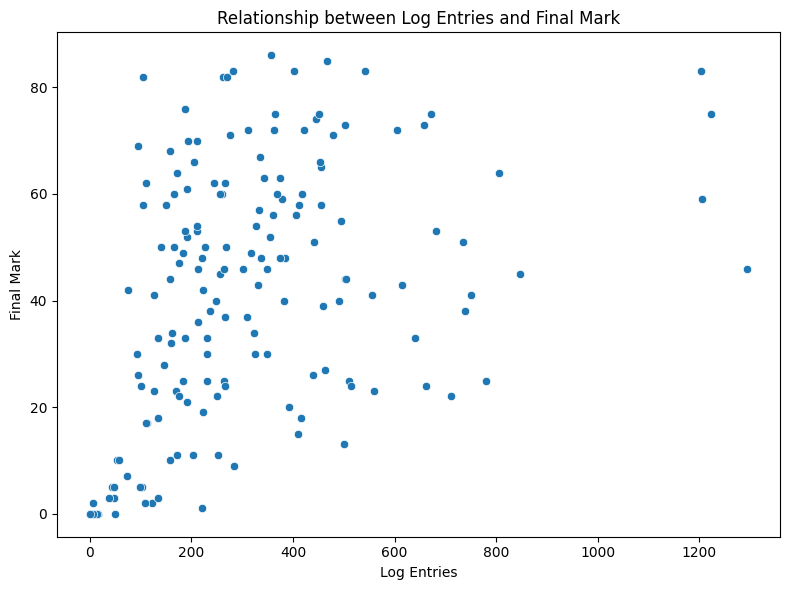

In [20]:
# plot scatter plot of log entries vs marks
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=student_level_df.dropna(subset=['Mark', 'Log Entries']),
    x='Log Entries',
    y='Mark'
)

plt.title('Relationship between Log Entries and Final Mark')
plt.xlabel('Log Entries')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

## Finding 4: Students with more LMS log entries tend to have higher marks, but log entries alone do not strongly explain marks

A moderate positive correlation of 0.408 was found between LMS log entries and final marks. This support the **Hypothesis 1**. the relationship is not strong enough to rely on log count alone for prediction, supporting the need to include additional indicators it mentioned. 

*Figure 2:*

/var/folders/nc/364srb_x0m926dqwk2stdknw0000gn/T/ipykernel_96555/1637682109.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)


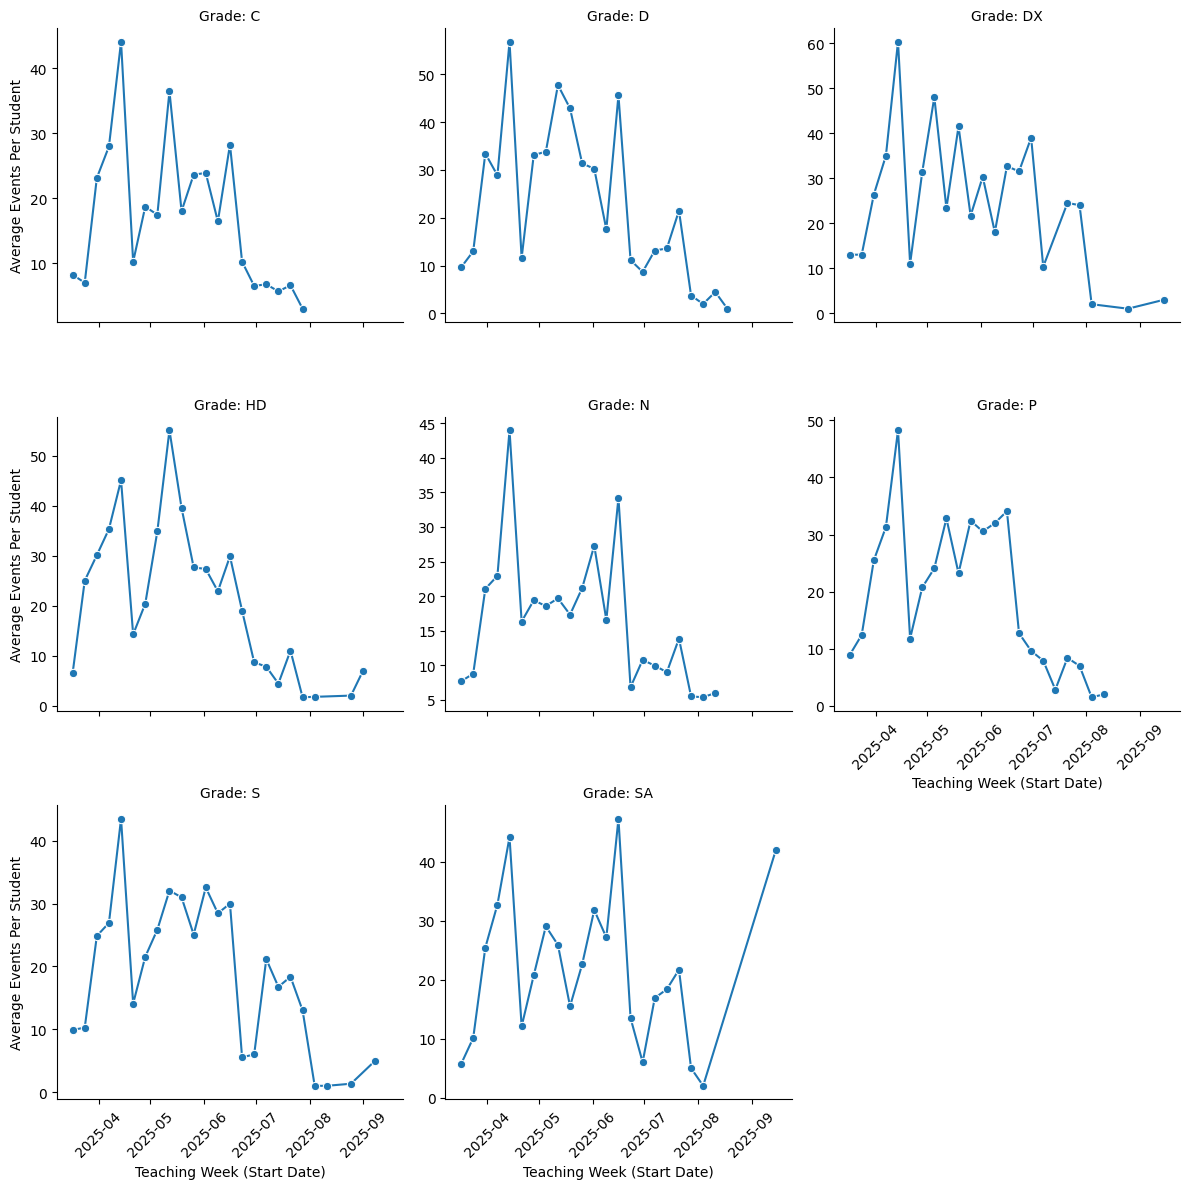

In [21]:
# compare weekly activity timeline for all grade categories (SA, P, D, HD, N, DX, etc.)
compare_students = student_level_df[['Person Id', 'Grade']].drop_duplicates().copy()
compare_students = compare_students.dropna(subset=['Grade'])
compare_students['Grade'] = compare_students['Grade'].astype(str).str.strip()

compare_logs = pd.merge(
    logs.copy(),
    compare_students,
    on='Person Id',
    how='inner'
)

compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)
compare_logs = compare_logs.dropna(subset=['Time'])

compare_logs['WeekStart'] = compare_logs['Time'].dt.to_period('W').dt.start_time
compare_weekly = (
    compare_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
 )

compare_weekly['Week'] = compare_weekly['WeekStart'].dt.strftime('%Y-%m-%d')

grade_order = sorted(compare_weekly['Grade'].unique().tolist())
compare_weekly['Grade'] = pd.Categorical(
    compare_weekly['Grade'],
    categories=grade_order,
    ordered=True
 )

# normalize by student count
weekly_student_activity = (
    compare_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_avg = (
    weekly_student_activity
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index()
)


import plotly.express as px

fig = px.line(
    weekly_avg,
    x='WeekStart',
    y='Events',
    color='Grade',
    markers=True,
    hover_data={'WeekStart': True, 'Events': True, 'Grade': True}
)

fig.update_layout(
    title='Average Weekly Events Per Student by Grade',
    xaxis_title='Teaching Week (Start Date)',
    yaxis_title='Average Events Per Student',
    legend_title='Grade'
)

fig.show()

# plot for multiple grade categories in multiple plots add tooltips 
g = sns.FacetGrid(
    weekly_avg,
    col='Grade',
    col_wrap=3,
    height=4,
    sharey=False
)
g.map(sns.lineplot, 'WeekStart', 'Events', marker='o')  
g.set_titles(col_template='Grade: {col_name}')
g.set_axis_labels('Teaching Week (Start Date)', 'Average Events Per Student')
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Finding 6: Average Weekly Events Per Student by Grade (Raw Event Counts Vs Normalized counts)

### Raw Event Counts

The figure 2 shows the total number of Moodle events generated each week for students in different grade categories. Across all grades, activity generally increased from March to June, peaked during major teaching and assessment periods, and declined sharply after later June. 

the N category consistenly generately the highest number of events, reaching almost 2,900 events during the week begining 14th April 2025. Other grade categories followed similar temporal patterns, with noticeable activity peaks around assessment periods. 

### Interpretation 
At first glance, the chart may suggest that students who received an N grade were the most active users of the LMS. However, this interpretation would be misleading because the grade categories contain different numbers of students. 

Dataset contains 42% of N grades than the other groups, it naturally generates more Moodle events overall. Therefore, the chart primarily reflects cohort size differences rather than individual student behavior. 

The chart is useful for understanding overall activity trends and identifying key periods of LMS usage throughout the semester. However, it is not suitable for comparing engagement behavior across grade categories becasue student population sizes vary consistenly. 


## Normalized Counts 

To remove the effect of equal cohort sizes, weekly counts were normalized by the number of students in each grade category. The resulting chart shows the average number of Moodle events generated per student each week. 

After normalization, the large differences observed in the previous chart become substantially smaller. Most grade categories follow very similar engagement pattterns throughout the semester. 

### Interpretation 
The normalized chart reveals that students across different grade categories generally interacted with Moodle at comparable levels. Again, although some variaion exists between grades in certain weeks, there is no clear seperation between high-performing and low-performing students based solely on LMS activity volume. 




### Diagnostics 1: Activity timeline by Grade 


In [22]:
# Why S and SA have higher logs entries than P and C? 
data_log = logs.copy()

data_log['Person Id'] = (
    data_log['Username']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype('string')
)

merged_df = pd.merge(
    results[['Person Id', 'Grade']].dropna(subset=['Person Id', 'Grade']),
    log_entries,
    on='Person Id',
    how='left'
)

merged_df['Person Id'] = (
    merged_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

# Merge raw logs with grade labels
grade_logs = pd.merge(
    data_log.copy(),
    merged_df[['Person Id', 'Grade']].drop_duplicates(),
    on='Person Id',
    how='inner'
)

# Convert Time column
grade_logs['Time'] = pd.to_datetime(
    grade_logs['Time'],
    errors='coerce',
    dayfirst=True
)

grade_logs = grade_logs.dropna(subset=['Time'])



/var/folders/nc/364srb_x0m926dqwk2stdknw0000gn/T/ipykernel_96555/2218714709.py:33: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [23]:
# check term start and end dates for S1 2025
term_dates = grade_logs['Time'].agg(['min', 'max'])
print(f"Term Start Date: {term_dates['min']}")
print(f"Term End Date: {term_dates['max']}")
print("Total days in term:", (term_dates['max'] - term_dates['min']).days)

Term Start Date: 2025-03-21 05:10:29
Term End Date: 2025-09-20 19:30:02
Total days in term: 183


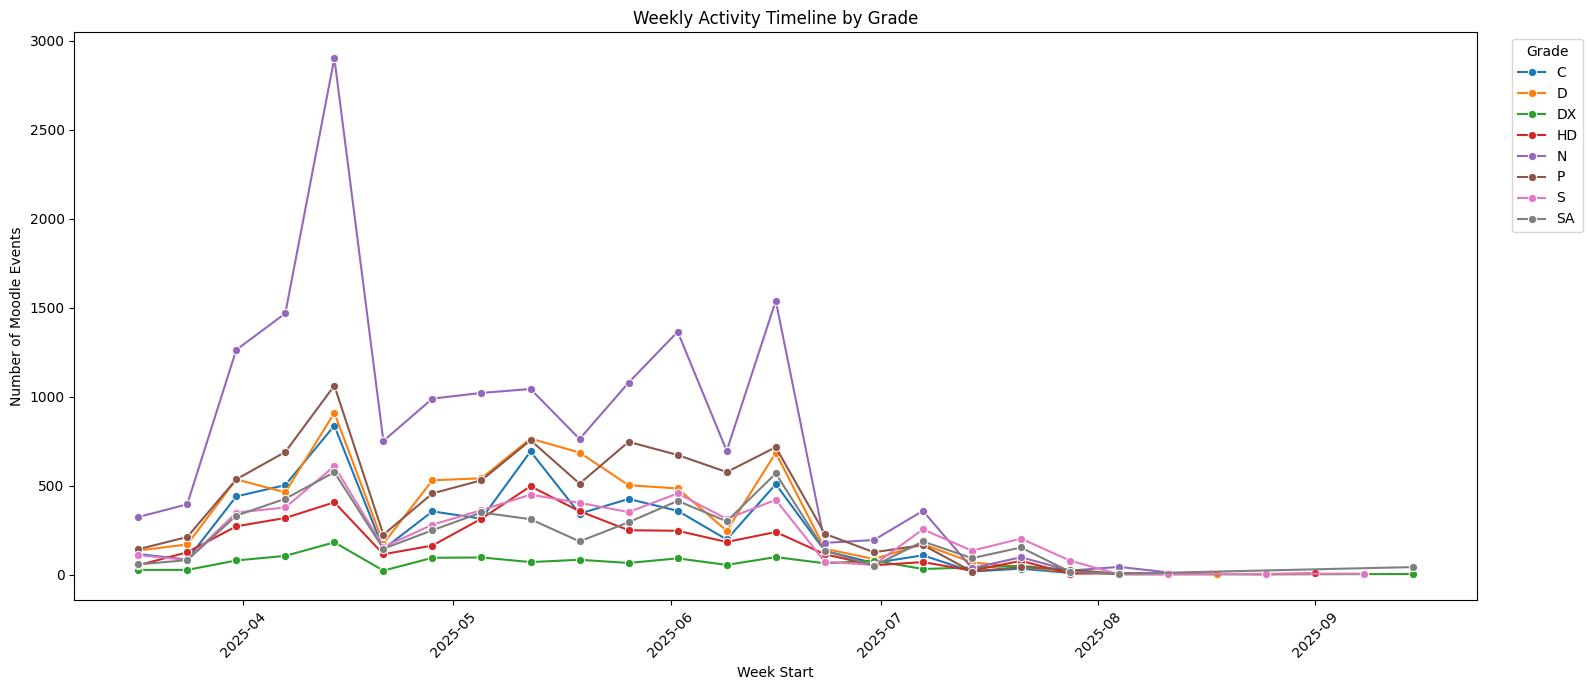

In [24]:
# weekly activity by grade category
grade_logs['WeekStart'] = grade_logs['Time'].dt.to_period('W').dt.start_time
weekly_grade_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
)   

weekly_grade_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Event Count')
)

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=weekly_grade_activity,
    x='WeekStart',
    y='Event Count',
    hue='Grade',
    marker='o'
)

plt.title('Weekly Activity Timeline by Grade')
plt.xlabel('Week Start')
plt.ylabel('Number of Moodle Events')
plt.xticks(rotation=45)
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

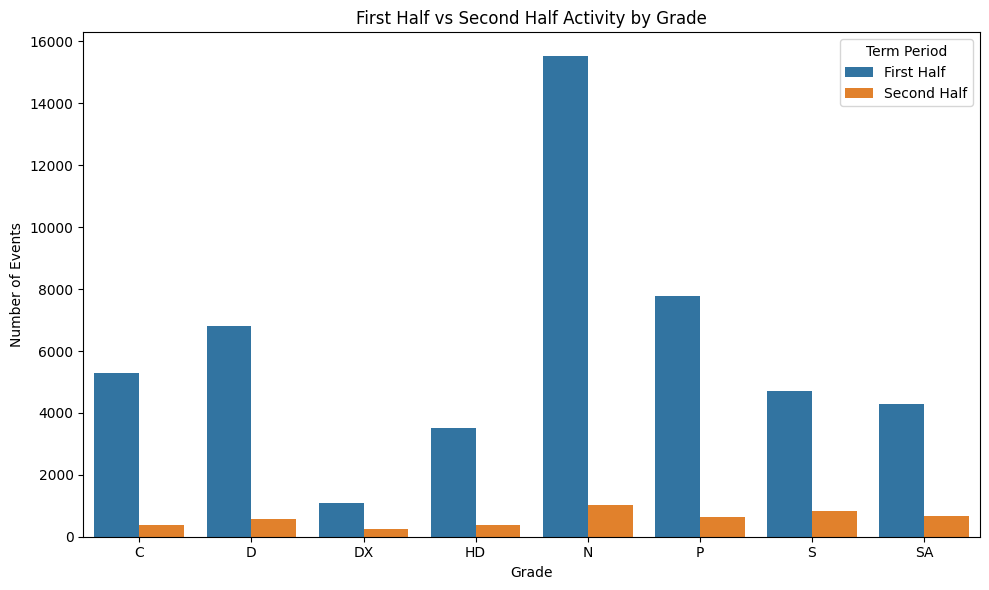

In [25]:
term_start = term_dates['min']
term_end = term_dates['max']
midpoint = term_start + (term_end - term_start) / 2

grade_logs['Term Period'] = np.where(
    grade_logs['Time'] < midpoint,
    'First Half',
    'Second Half'
)

period_activity = (
    grade_logs
    .groupby(['Grade', 'Term Period'])
    .size()
    .reset_index(name='Event Count')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=period_activity,
    x='Grade',
    y='Event Count',
    hue='Term Period'
)

plt.title('First Half vs Second Half Activity by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

In [26]:
# calculate active weeks for each student 
if 'WeekStart' in grade_logs.columns:
    active_weeks = grade_logs.groupby('Person Id')['WeekStart'].nunique()
else:
    active_weeks = (
        grade_logs.assign(
            Time=pd.to_datetime(grade_logs['Time'], errors='coerce', dayfirst=True)
        )
        .dropna(subset=['Time'])
        .groupby('Person Id')['Time']
        .apply(lambda x: x.dt.isocalendar().week.nunique())
    )

active_weeks.describe()

count    168.000000
mean      14.273810
std        4.424621
min        1.000000
25%       12.000000
50%       16.000000
75%       17.000000
max       23.000000
Name: WeekStart, dtype: float64

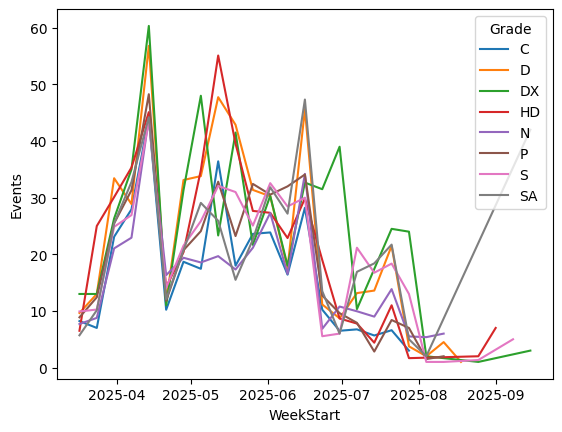

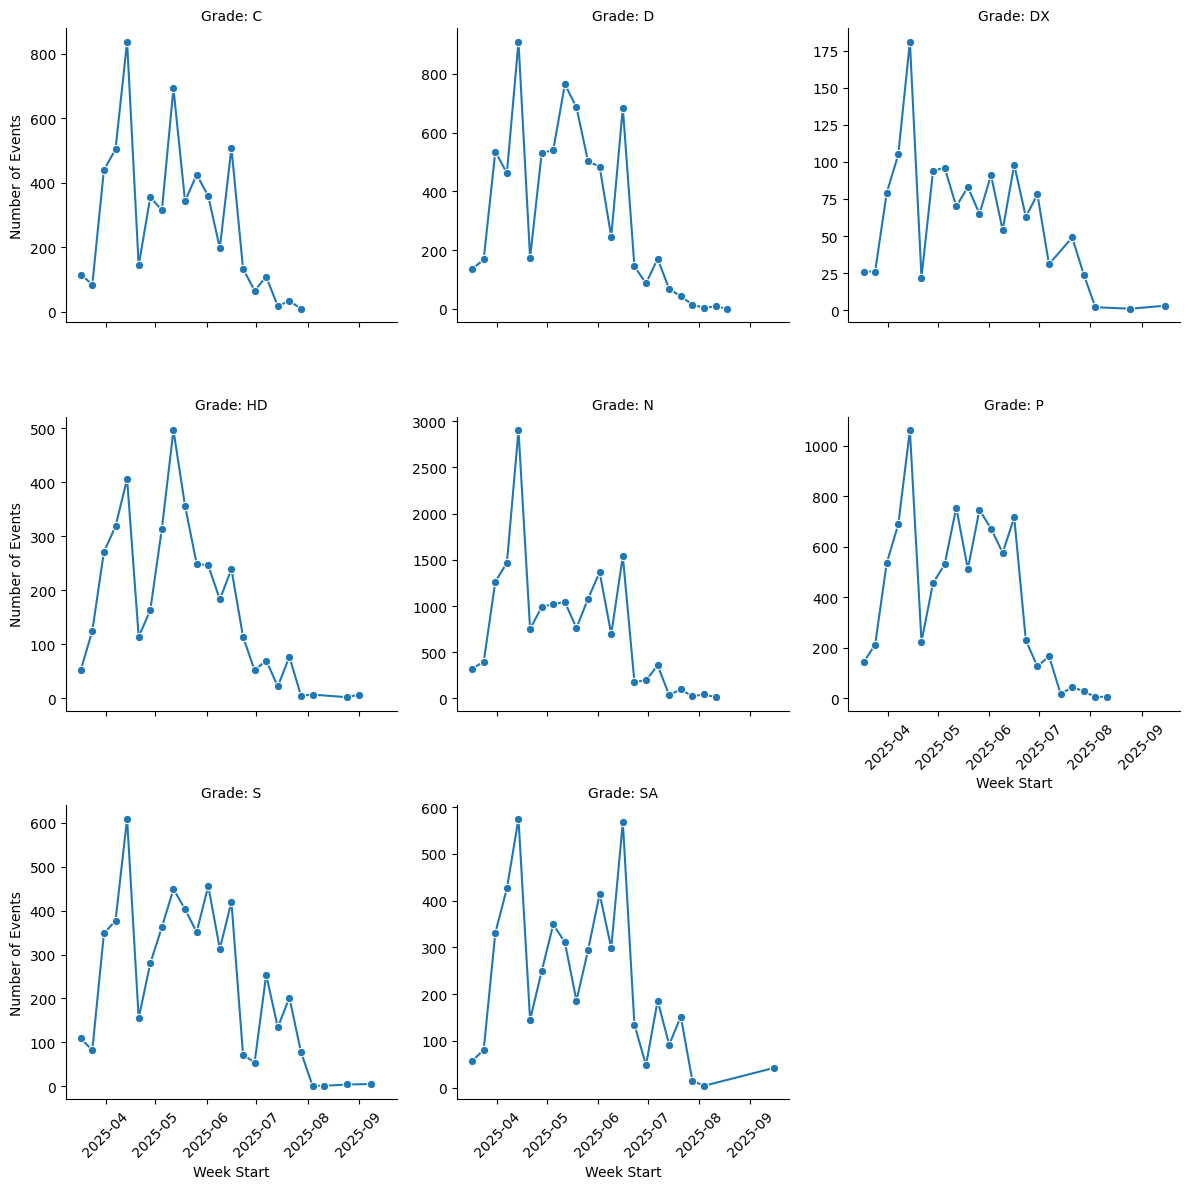

In [27]:
weekly_student_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_avg = (
    weekly_student_activity
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=weekly_avg,
    x='WeekStart',
    y='Events',
    hue='Grade'
)

# create small multiples of weekly activity by grade category
g = sns.FacetGrid(weekly_grade_activity, col='Grade', col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, 'WeekStart', 'Event Count', marker='o')
g.set_titles('Grade: {col_name}')
g.set_axis_labels('Week Start', 'Number of Events')
for ax in g.axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [28]:
student_active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

student_active_weeks.groupby('Grade')['Active Weeks'].mean()

Grade
C     14.947368
D     16.687500
DX    16.666667
HD    17.666667
N     11.535211
P     15.739130
S     17.428571
SA    16.384615
Name: Active Weeks, dtype: float64

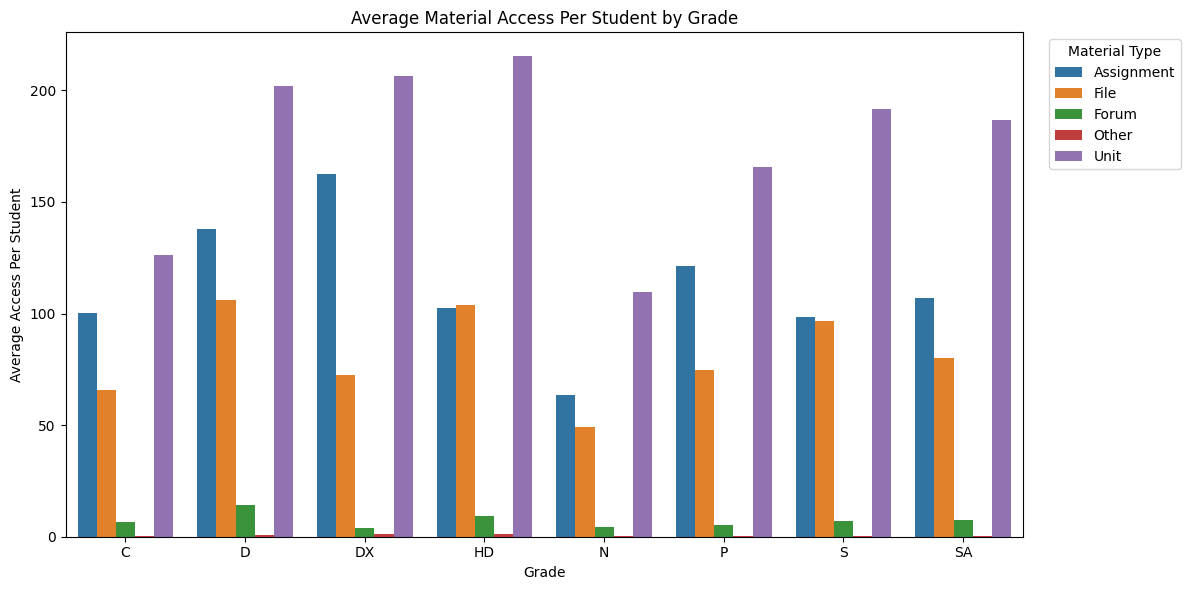

In [29]:
import pandas as pd

import matplotlib.pyplot as plt

logs = pd.read_excel('ICT001 S1 2025 Logs RELEASED V1.0.xlsx')
results = pd.read_excel('ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx', header=2)

results['Person Id'] = (
    results['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype('string')
    .str.strip()
)

results['Person Id'] = (
    results['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

def classify_material(event_context):
    if pd.isna(event_context):
        return 'Other'
    
    context = str(event_context).strip().lower()
    prefix = context.split(':', 1)[0].strip()

    mapping = {
        'file': 'File',
        'page': 'Page',
        'url': 'URL',
        'folder': 'Folder',
        'book': 'Book',
        'quiz': 'Quiz',
        'assignment': 'Assignment',
        'forum': 'Forum',
        'lesson': 'Lesson',
        'unit': 'Unit'
    }

    return mapping.get(prefix, 'Other')

logs['Material Type'] = logs['Event context'].apply(classify_material)

if 'Person Id' not in logs.columns and 'Username' in logs.columns:
    logs['Person Id'] = (
        logs['Username']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )

student_material = (
    logs.dropna(subset=['Person Id', 'Material Type'])[['Person Id', 'Material Type']]
    .merge(
        results.dropna(subset=['Person Id', 'Grade'])[['Person Id', 'Grade']],
        on='Person Id',
        how='inner'
    )
)

material_per_student = (
    student_material
    .groupby(['Grade', 'Material Type'])['Person Id']
    .count()
    .reset_index(name='Accesses')
)

grade_counts = (
    results.groupby('Grade')['Person Id']
    .nunique()
    .reset_index(name='Students')
)

material_per_student = material_per_student.merge(
    grade_counts,
    on='Grade',
    how='left'
)

material_per_student['Avg Access Per Student'] = (
    material_per_student['Accesses'] / material_per_student['Students']
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=material_per_student,
    x='Grade',
    y='Avg Access Per Student',
    hue='Material Type'
)

plt.title('Average Material Access Per Student by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Access Per Student')
plt.legend(title='Material Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 

## Finding 7: Average Material Access Per Student by Grade 

This chart compares the average number of accesses per student for each material type across grade categories. 

### Key observations 
1. Course/Unit Pages are the most accessed resource all grades 
2. Assignment access shows the clear relationship with academic performance 
>> D, HD and even DX have noticeably higher assignment access than N students. 
>> This suggests that assignment related interactions may be a strong indicator of early warning and intervention tool rather than stanalone grade prediction mechanism. 






In [30]:
active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

active_weeks_summary = (
    active_weeks
    .groupby('Grade')['Active Weeks']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

active_weeks_summary

active_weeks_summary

,count,mean,median,min,max
Grade,,,,,
HD,9,17.666667,18.0,13,21
S,14,17.428571,17.0,13,23
D,16,16.687500,17.0,12,20
DX,3,16.666667,16.0,13,21
SA,13,16.384615,18.0,10,19
P,23,15.739130,17.0,6,19
C,19,14.947368,16.0,9,18
N,71,11.535211,13.0,1,18


In [31]:
# check the time student accessed assignment materials and group by grade category - normalize by student count in each grade category


if 'logs' in globals():
    log_df = logs.copy()

elif 'data_log' in globals():
    log_df = data_log.copy()

else:
    raise NameError("No log dataframe found. Please load logs or data_log first.")

# Choose correct results datafram
if 'results' in globals():
    results_df = results.copy()

elif 'results_data' in globals():
    results_df = globals()['results_data'].copy()

else:
    raise NameError("No results dataframe found. Please load results or results_data first.")

# Clean Person Id
log_df['Person Id'] = (
    log_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

results_df['Person Id'] = (
    results_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

# Convert Time
log_df['Time'] = pd.to_datetime(
    logs['Time'],
    format='%d/%m/%y, %H:%M:%S',
    errors='coerce'

)

log_df = log_df.dropna(subset=['Time', 'Person Id'])

# Merge grade and mark into logs
grade_logs = log_df.merge(
    results_df[['Person Id', 'Grade', 'Mark']],
    on='Person Id',
    how='inner'
)

grade_logs['Mark'] = pd.to_numeric(grade_logs['Mark'], errors='coerce')

# Create week
grade_logs['WeekStart'] = (
    grade_logs['Time']
    .dt.to_period('W')
    .dt.start_time

)

In [32]:
logs['Time'].head(10)

0    13/11/25, 09:55:28
1    20/09/25, 19:30:02
2    20/09/25, 19:29:35
3    20/09/25, 19:29:08
4    20/09/25, 19:29:04
5    20/09/25, 19:28:42
6    20/09/25, 19:28:18
7    20/09/25, 19:28:14
8    20/09/25, 19:27:50
9    20/09/25, 19:27:16
Name: Time, dtype: object

In [33]:
# assignment access timing 
assignment_logs = grade_logs[
    (grade_logs['Component'].astype(str).str.contains('Assignment', case=False, na=False)) |
    (grade_logs['Event context'].astype(str).str.contains('assignment', case=False, na=False))
].copy()

first_assignment_access = (
    assignment_logs
    .groupby(['Person Id', 'Grade', 'Mark'])['Time']
    .min()
    .reset_index(name='First Assignment Access')
)

term_start = grade_logs['Time'].min()

first_assignment_access['Days From Term Start'] = (
    first_assignment_access['First Assignment Access'] - term_start
).dt.days

first_assignment_access.head()

,Person Id,Grade,Mark,First Assignment Access,Days From Term Start
0,15925001,P,52.0,2025-04-14 12:32:13,24
1,15925002,N,38.0,2025-03-21 13:30:56,0
2,15925003,N,2.0,2025-04-07 17:48:26,17
3,15925004,S,46.0,2025-03-21 10:02:20,0
4,15925005,S,45.0,2025-03-21 13:55:06,0


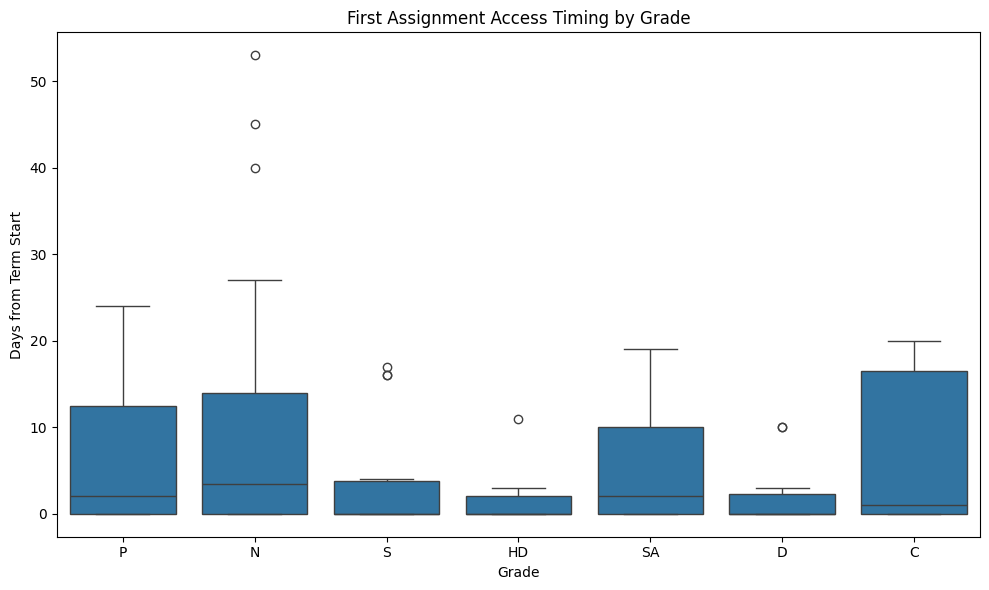

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=first_assignment_access,
    x='Grade',
    y='Days From Term Start'
)

plt.title('First Assignment Access Timing by Grade')
plt.xlabel('Grade')
plt.ylabel('Days from Term Start')
plt.tight_layout()
plt.show()

### Observation: 
High-performaning students tend to access earlier
N students show the largest delay variation 
C students have unusual behavior - many accessed early but spread very large, some waited nearly 20 days. 


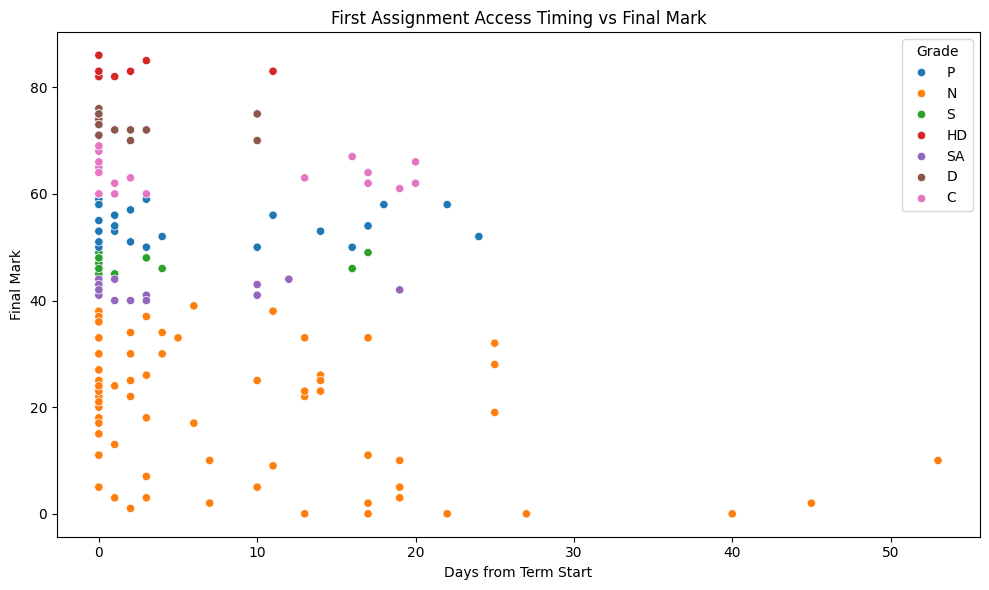

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=first_assignment_access,
    x='Days From Term Start',
    y='Mark',
    hue='Grade'
)

plt.title('First Assignment Access Timing vs Final Mark')
plt.xlabel('Days from Term Start')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [36]:
first_assignment_access[['Days From Term Start', 'Mark']].corr()

,Days From Term Start,Mark
Days From Term Start,1.00000,-0.32413
Mark,-0.32413,1.00000


## Finding 8: Early Assignment Engagment is Associated with Better Academic Performance 
To investigate whether early enagagment with assignment materials influences student performance, the timing of student's first assignment accesss was analyzed against their final marks. The results show a moderate negative correlation between the number of days taken to first access assignment materials and final mark (r = - 0.324). 

Students who accessed assignment materials shortly after the commencement of the teaching period generally achieved higher final marks, while students who delayed accessing assignment information tended to achieve lower marks. Several students who first accessed assignment material more than 20 days after the start of the term obtained failing grades or very low marks. 

However, the relationship is not sufficiently strong to conclude that assignment access timing alone determines student success. Several students accessed assignments early but still achieved poor outcomes, indicating that additional factors such as quiz performance, assignment scores, overall activity levels, and sustained engagment throughout the semester also influence academic achievement. 

>>These finding suggests that delayed assignment engagment may serve as an early indicator of academic risk and could be incorporated as one of several predictive features within an AI-based student risk prediction model. 


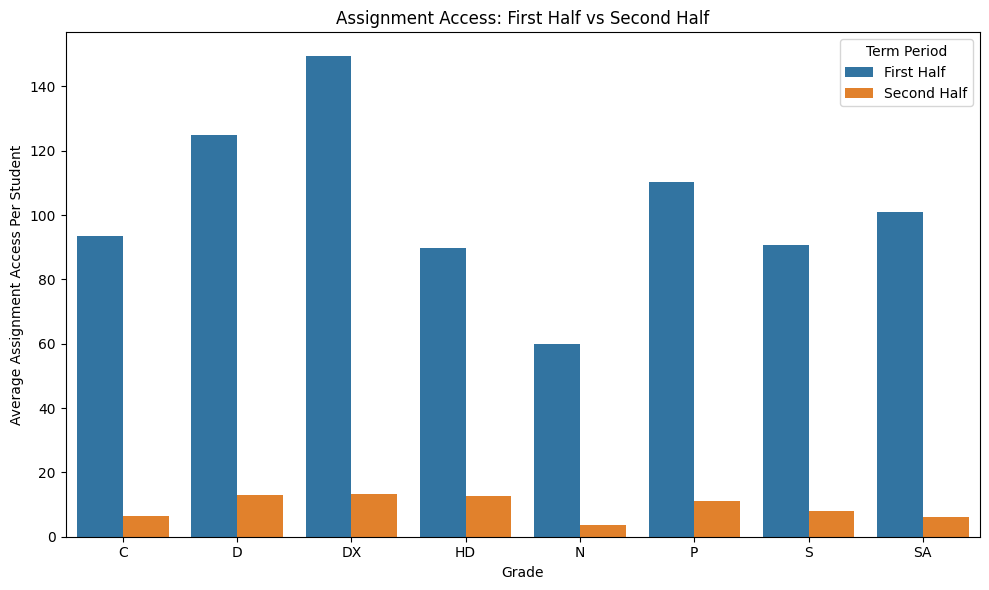

In [37]:
midpoint = term_start + (grade_logs['Time'].max() - term_start) / 2

assignment_logs['Term Period'] = np.where(
    assignment_logs['Time'] < midpoint,
    'First Half',
    'Second Half'
)

assignment_period = (
    assignment_logs
    .groupby(['Grade', 'Term Period'])['Person Id']
    .count()
    .reset_index(name='Assignment Access Count')
)

grade_counts = (
    results_df
    .groupby('Grade')['Person Id']
    .nunique()
    .reset_index(name='Students')
)

assignment_period = assignment_period.merge(grade_counts, on='Grade', how='left')

assignment_period['Avg Assignment Access Per Student'] = (
    assignment_period['Assignment Access Count'] / assignment_period['Students']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=assignment_period,
    x='Grade',
    y='Avg Assignment Access Per Student',
    hue='Term Period'
)

plt.title('Assignment Access: First Half vs Second Half')
plt.xlabel('Grade')
plt.ylabel('Average Assignment Access Per Student')
plt.tight_layout()
plt.show()

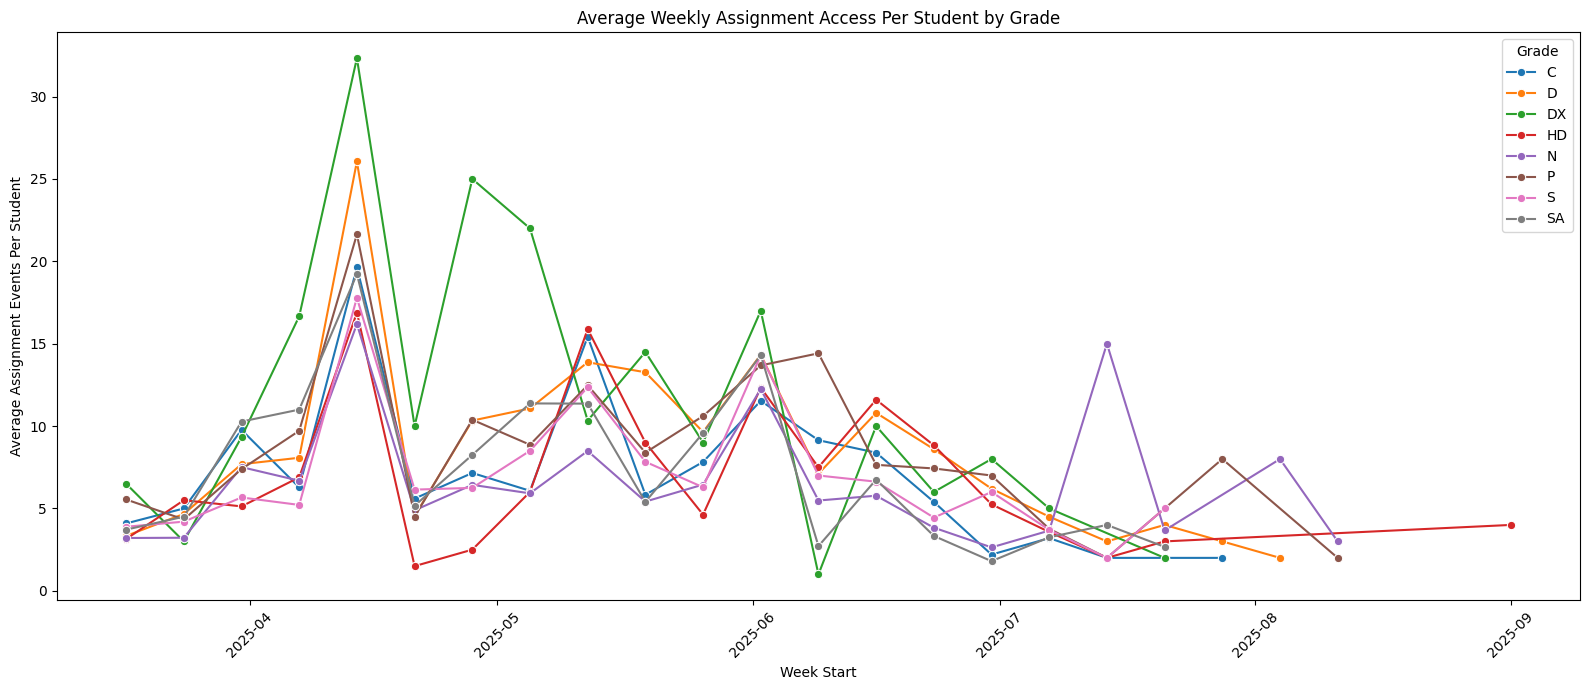

In [38]:
weekly_assignment = (
    assignment_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_assignment_avg = (
    weekly_assignment
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index(name='Avg Assignment Events Per Student')
)

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=weekly_assignment_avg,
    x='WeekStart',
    y='Avg Assignment Events Per Student',
    hue='Grade',
    marker='o'
)

plt.title('Average Weekly Assignment Access Per Student by Grade')
plt.xlabel('Week Start')
plt.ylabel('Average Assignment Events Per Student')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Finding 9: Early Learning Material Access Has Limited Predictive Value

Analysis of students' first learning material access showed a weak negative correlation with final marks (r= -0.24). Students who accessed learning materials earlier generally achieved slighly higher marks; however, substantial overlap existed across all grade categories. Many low-performaning students accessed materials early, while high-performing students delayed access without significant impact on performance. 

These finding suggests that learning material access timing alone is not a reliable predictor of academic success. More meaningful indicators are needed. While extremely delayed access may signal potential academic risk, this features should be used as a supplementary indicator if necesssary. 

In [39]:


material_logs = grade_logs.copy()

# make sure time is datetime
material_logs['Time'] = pd.to_datetime(
    material_logs['Time'],
    errors='coerce'
)

# classify materials if not already available
if 'Material Type' not in material_logs.columns:
    material_logs['Material Type'] = material_logs['Event context'].apply(classify_material)

# keep only meaningful learning materials
material_logs = material_logs[
    material_logs['Material Type'].isin([
        'Assignment',
        'Quiz',
        'Recorded Session',
        'Lecture Material',
        'File',
        'Forum'
    ])
].copy()

# use Event context as material identifier
material_logs['Material Name'] = material_logs['Event context'].astype(str)

# approximate release date = first access by anyone
material_release = (
    material_logs
    .groupby('Material Name')['Time']
    .min()
    .reset_index(name='Estimated Release Date')
)

# first access by each student for each material
student_material_first_access = (
    material_logs
    .groupby(['Person Id', 'Grade', 'Mark', 'Material Name', 'Material Type'])['Time']
    .min()
    .reset_index(name='Student First Access')
)

# merge release date
student_material_first_access = student_material_first_access.merge(
    material_release,
    on='Material Name',
    how='left'
)

# calculate delay in days
student_material_first_access['Access Delay Days'] = (
    student_material_first_access['Student First Access']
    - student_material_first_access['Estimated Release Date']
).dt.days

student_material_first_access.head()

,Person Id,Grade,Mark,Material Name,Material Type,Student First Access,Estimated Release Date,Access Delay Days
0,15925001,P,52.0,Assignment: Assessed Exercise Week 10 (for stu...,Assignment,2025-05-08 09:26:09,2025-04-13 08:33:27,25
1,15925001,P,52.0,Assignment: Assessed Exercise Week 11 (for stu...,Assignment,2025-05-08 09:52:00,2025-04-28 12:15:29,9
2,15925001,P,52.0,Assignment: Assessed Exercise Week 12 (for stu...,Assignment,2025-05-08 09:54:04,2025-04-28 14:14:53,9
3,15925001,P,52.0,Assignment: Assessed Exercise Week 13 (for stu...,Assignment,2025-05-08 09:26:48,2025-04-13 15:55:00,24
4,15925001,P,52.0,Assignment: Assessed Exercise Week 14 (for stu...,Assignment,2025-06-19 19:18:20,2025-05-25 18:35:03,25


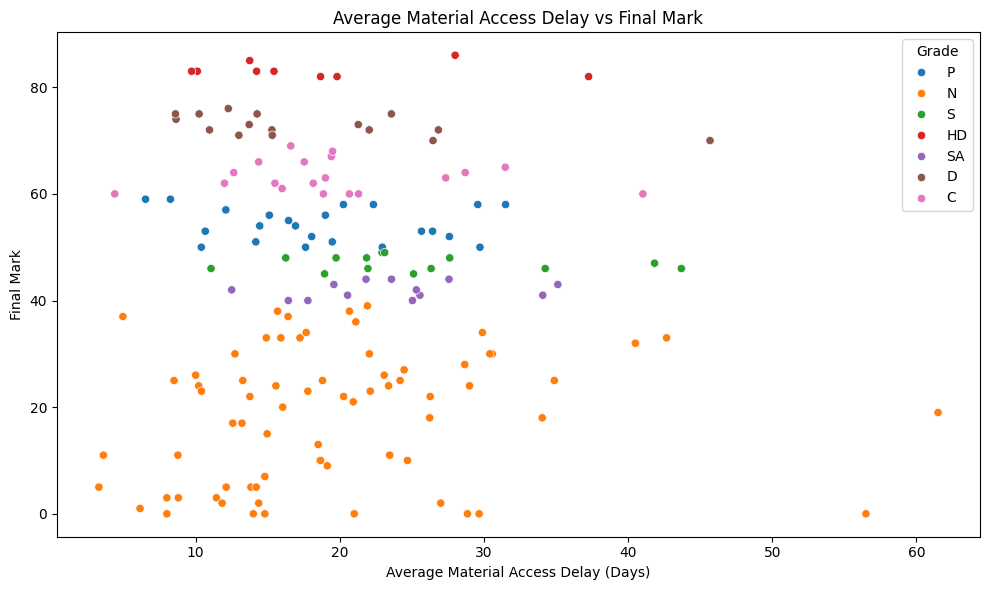

In [40]:
plt.figure(figsize=(10, 6))

if 'student_delay_summary' not in globals():
    student_delay_summary = (
        student_material_first_access
        .groupby(['Person Id', 'Grade', 'Mark'], as_index=False)
        .agg(
            Avg_Material_Access_Delay=('Access Delay Days', 'mean'),
            Median_Material_Access_Delay=('Access Delay Days', 'median'),
            Materials_Accessed=('Material Name', 'nunique')
        )
    )

student_delay_summary['Mark'] = pd.to_numeric(student_delay_summary['Mark'], errors='coerce')

sns.scatterplot(
    data=student_delay_summary.dropna(subset=['Avg_Material_Access_Delay', 'Mark', 'Grade']),
    x='Avg_Material_Access_Delay',
    y='Mark',
    hue='Grade'
)

plt.title('Average Material Access Delay vs Final Mark')
plt.xlabel('Average Material Access Delay (Days)')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [41]:
student_material_first_access['Accessed Within 7 Days'] = (
    student_material_first_access['Access Delay Days'] <= 7
)

early_access_summary = (
    student_material_first_access
    .groupby(['Person Id', 'Grade', 'Mark'])
    .agg(
        Materials_Accessed=('Material Name', 'nunique'),
        Materials_Accessed_Within_7_Days=('Accessed Within 7 Days', 'sum')
    )
    .reset_index()
)

early_access_summary['Pct_Materials_Accessed_Within_7_Days'] = (
    early_access_summary['Materials_Accessed_Within_7_Days']
    / early_access_summary['Materials_Accessed']
) * 100

early_access_summary[['Pct_Materials_Accessed_Within_7_Days', 'Mark']].corr()

,Pct_Materials_Accessed_Within_7_Days,Mark
Pct_Materials_Accessed_Within_7_Days,1.000000,0.155193
Mark,0.155193,1.000000


In [42]:
student_delay_summary = (
    student_material_first_access
    .groupby(['Person Id', 'Grade', 'Mark'])
    .agg(
        Avg_Material_Access_Delay=('Access Delay Days', 'mean'),
        Median_Material_Access_Delay=('Access Delay Days', 'median'),
        Materials_Accessed=('Material Name', 'nunique')
    )
    .reset_index()
)

student_delay_summary[['Avg_Material_Access_Delay', 'Mark']].corr()

,Avg_Material_Access_Delay,Mark
Avg_Material_Access_Delay,1.000000,-0.000141
Mark,-0.000141,1.000000


## Finding 10: Access Delay Day Vs Mark Relationship

Average material access delay showed virtually no relationship with final mark (r =0.0001). This suggests that the average timing of material access is not a strong indicator of academic performance. Therefore, this feature is unlikely to provide significant predictive value for identifying at-risk students. 

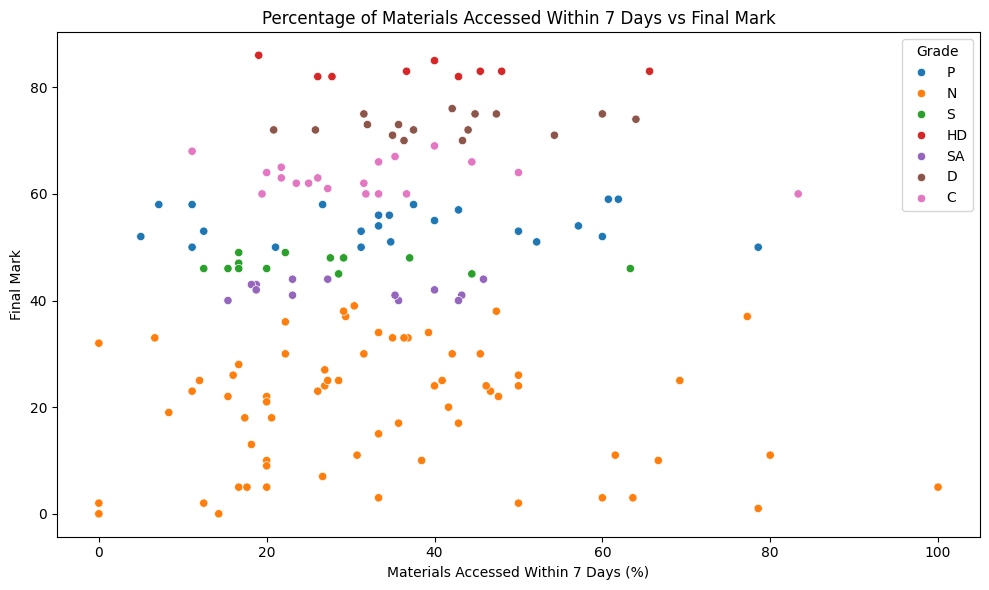

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=early_access_summary,
    x='Pct_Materials_Accessed_Within_7_Days',
    y='Mark',
    hue='Grade'
)

plt.title('Percentage of Materials Accessed Within 7 Days vs Final Mark')
plt.xlabel('Materials Accessed Within 7 Days (%)')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()


## Finding 11: Material Accessed Within 30 days Vs Mark Relationship
The percentage of materials accessed within seven days of release showed only a week positive relationship with final marks (r = 0.154). While timely access may reflect positive study habits, the feature does not appear to be a strong academic performance. 


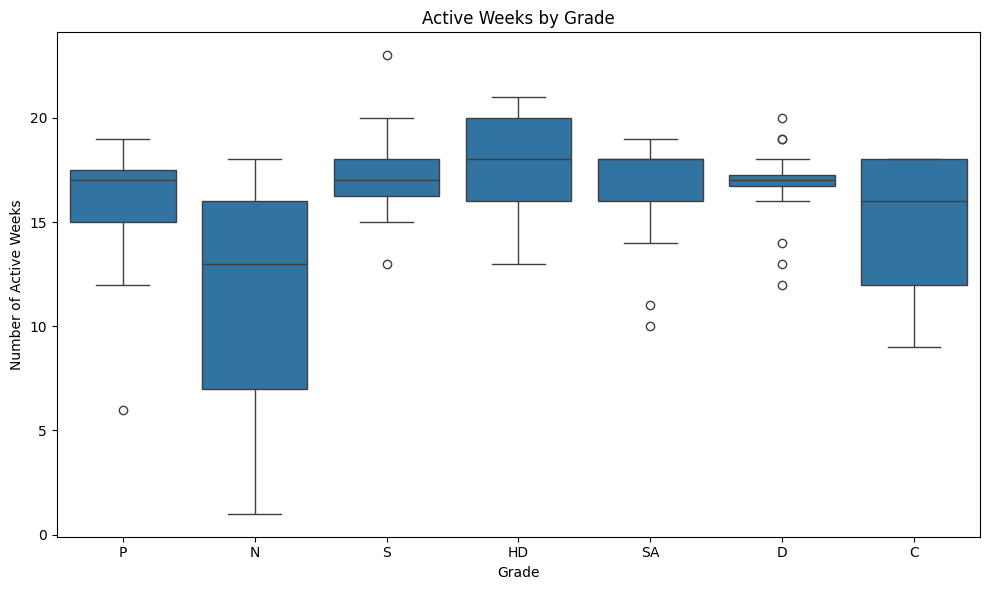

In [44]:
student_active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade', 'Mark'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

student_active_weeks.groupby('Grade')['Active Weeks'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=student_active_weeks,
    x='Grade',
    y='Active Weeks'
)

plt.title('Active Weeks by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Active Weeks')
plt.tight_layout()
plt.show()

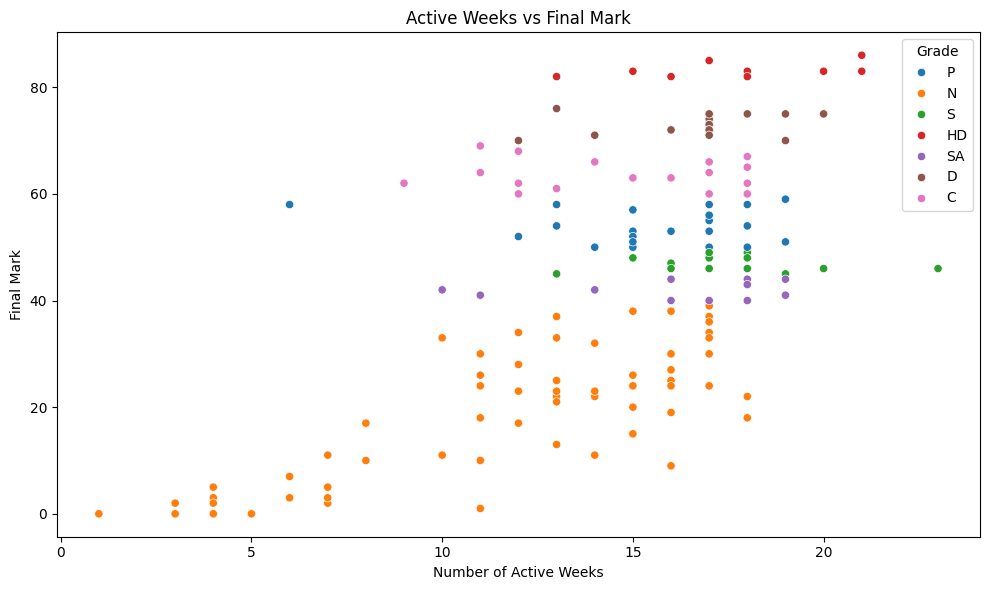

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=student_active_weeks,
    x='Active Weeks',
    y='Mark',
    hue='Grade'
)

plt.title('Active Weeks vs Final Mark')
plt.xlabel('Number of Active Weeks')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [46]:
student_active_weeks[['Active Weeks', 'Mark']].corr()

,Active Weeks,Mark
Active Weeks,1.000000,0.647034
Mark,0.647034,1.000000


## Finding 12: Sustained Weekly Engagement is Strongly Associated with Academic Performance

To investigate whether consistent LMS engagment influences academic performance, the number of active weeks per student was calculated and compared against final marks. 

The anlysis revealed a moderately strong positive correlation between active weeks and final mark (r= 0.647), indicating that student who engaged with LMS across more weeks generally achieved higher academic outcomes. 

Students achieving HD, D and SA grades typically remained active for approximately 16-20 weeks throughout the semester. In constrast, students receiving N grades exhibited substantially lower and more variable engagment, with some students active for fewer than five weeks. 

These finding suggests that sustained engagement across the semester is strong indicator of academic success and should be considered a key feature in student risk prediction models. 

In [47]:
student_features = (
    results_df[['Person Id', 'Grade', 'Mark']]
    .merge(
        student_active_weeks[['Person Id', 'Active Weeks']],
        on='Person Id',
        how='left'
    )
    .merge(
        first_assignment_access[['Person Id', 'Days From Term Start']]
        .rename(columns={'Days From Term Start': 'Days To First Assignment Access'}),
        on='Person Id',
        how='left'
    )

        .merge(
            early_access_summary[['Person Id', 'Pct_Materials_Accessed_Within_7_Days']],
            on='Person Id',
            how='left'
        )
)

student_features.head()

,Person Id,Grade,Mark,Active Weeks,Days To First Assignment Access,Pct_Materials_Accessed_Within_7_Days
0,15925001,P,52.0,12.0,24.0,5.000000
1,15925002,N,38.0,15.0,0.0,47.368421
2,15925003,N,2.0,7.0,17.0,12.500000
3,15925004,S,46.0,23.0,0.0,63.333333
4,15925005,S,45.0,13.0,0.0,44.444444


In [48]:
quiz_col = 'Weekly Lab Quizzes / 100'

results[['Grade', quiz_col]].groupby('Grade').mean()

,Weekly Lab Quizzes / 100
Grade,
C,71.442105
D,88.012500
DX,57.500000
HD,91.388889
N,28.952055
P,67.386957
S,66.135714
SA,67.269231


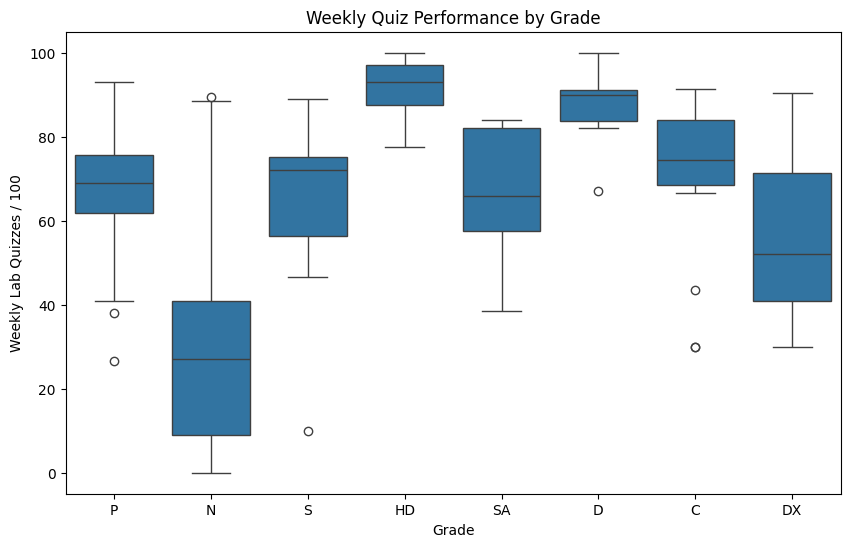

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results,
    x='Grade',
    y=quiz_col
)

plt.title('Weekly Quiz Performance by Grade')
plt.show()

In [50]:
results[['Mark', quiz_col]].corr()

,Mark,Weekly Lab Quizzes / 100
Mark,1.00000,0.83374
Weekly Lab Quizzes / 100,0.83374,1.00000


## Finding 13: Weekly Quiz Performance is strongly associated with academic performance 
The analysis showed a strong relationship between weekly quiz performance and final academic outcomes. Students achieving higher grades generally obtained higher weekly quiz scores, while student receiving N grades recorded substantially lower quiz performance. 

The correlation between weekly quiz scores and final marks was 0.833, indicating a very strong positive association. 

However, this result should be interpreted with caution because weekly quiz scores contribute directly to the calculation of the final course mark. Consequently, part of this relationship is expected due to the assessment structure rather than purely student engagment behavior. 

Since quiz results become available progressively throughout the teaching period, they may provide useful signals for future prediction models to predict student grades. The observed relationship may also be influenced by data leakage, as predictor variables contain information that is already incorporated into the target variable being predicted. 


In [51]:
# assignment 1 vs final mark correlation
assignment_col = 'Assignment 1 / 100'
tmp = results[['Mark', assignment_col]].copy()
tmp['Mark'] = pd.to_numeric(tmp['Mark'], errors='coerce')
tmp[assignment_col] = pd.to_numeric(tmp[assignment_col], errors='coerce')

tmp.dropna(subset=['Mark', assignment_col]).corr()


,Mark,Assignment 1 / 100
Mark,1.000000,0.612789
Assignment 1 / 100,0.612789,1.000000


In [52]:
# assignment 2 vs final mark correlation
assignment_col = 'Assignment 2 / 100'
# resolve actual Assignment 2 column name safely
candidate_cols = [assignment_col, 'Ass 2 /100', 'Ass 2/100', 'Ass 2 with Penalty /100']
assignment_col = next((c for c in candidate_cols if c in results.columns), None)

if assignment_col is None:
    raise KeyError(f"None of the expected Assignment 2 columns found. Available columns: {results.columns.tolist()}")

tmp = results[['Mark', assignment_col]].copy()
tmp['Mark'] = pd.to_numeric(tmp['Mark'], errors='coerce')
tmp[assignment_col] = pd.to_numeric(tmp[assignment_col], errors='coerce')   
tmp.dropna(subset=['Mark', assignment_col]).corr()  

,Mark,Ass 2 /100
Mark,1.000000,0.691885
Ass 2 /100,0.691885,1.000000


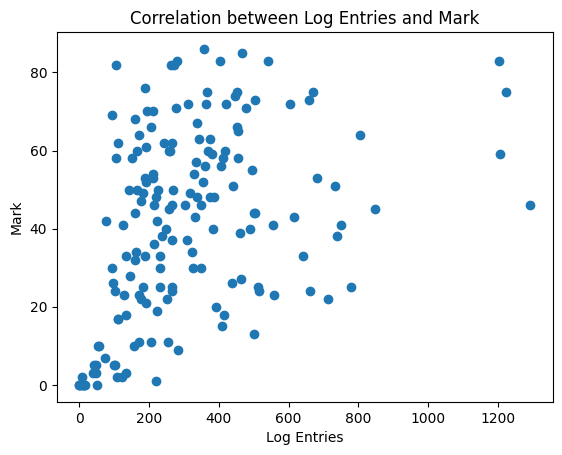

In [53]:
# plot correlation log entries vs mark
plt.scatter(analysis_df['Log Entries'], analysis_df['Mark'])
plt.xlabel('Log Entries')
plt.ylabel('Mark')
plt.title('Correlation between Log Entries and Mark')
plt.show()


In [54]:
# calculate correlation between log entries and mark
corr_df = student_level_df[['Log Entries', 'Mark']].copy()
corr_df['Log Entries'] = pd.to_numeric(corr_df['Log Entries'], errors='coerce')
corr_df['Mark'] = pd.to_numeric(corr_df['Mark'], errors='coerce')

corr_df.dropna(subset=['Log Entries', 'Mark']).corr()

,Log Entries,Mark
Log Entries,1.000000,0.408232
Mark,0.408232,1.000000


## Finding 14: Relationship between Log Entries and Final Marks 
The analysis shows a moderate postive relationship between total log entries and final marks (r=0.408). 

However, the relationship is relatively weak compared to indicators like the number of active weeks. The scatterplot demonstrates that students with very high numbers of log entries can still achieve a wide range of academic outcomes, suggesting that simply generating more LMS activity does not gurantee stronger performance. 

This finding suggests that engagement consistency is a more meaningful indicator of academic success than total activity volume.

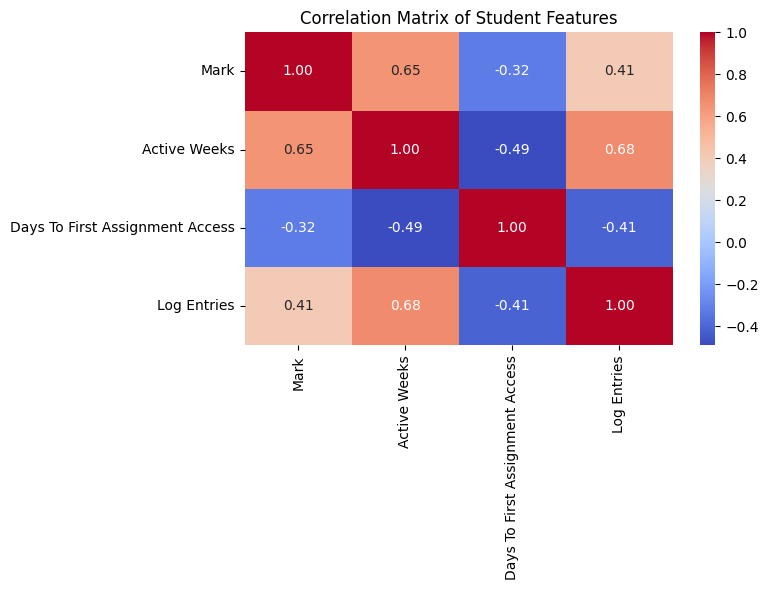

In [55]:
corr_df = student_features.copy()

coor_df = corr_df.rename(columns={
    'Mark': 'Mark',
    'Active Weeks': 'Active Weeks',
    'Days To First Assignment Access': 'Days To First Assignment Access',
    'Days To First File Access': 'Days To First File Access'
})

# add Log Entries if it is not already in student_features
if 'Log Entries' not in corr_df.columns and 'student_level_df' in globals():
    corr_df = corr_df.merge(
        student_level_df[['Person Id', 'Log Entries']].drop_duplicates(),
        on='Person Id',
        how='left'
    )

cols = [
    'Mark',
    'Active Weeks',
    'Days To First Assignment Access',
    'Days To First File Access',
    'Log Entries'   # fixed from 'log_entries'
]

existing_cols = [c for c in cols if c in corr_df.columns]
corr_matrix = corr_df[existing_cols].apply(pd.to_numeric, errors='coerce').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Student Features')
plt.tight_layout()
plt.show()

In [56]:
correlation_summary = pd.DataFrame({
    'Feature': [
        'Weekly Quiz Score',
        'Assignment 2 Score',
        'Active Weeks',
        'Assignment 1 Score',
        'Log Entries',
        'First Assignment Access Timing',
        'First File Access Timing'
    ],
    'Correlation': [
        0.834,
        0.692,
        0.647,
        0.613,
        0.408,
        -0.324,
        -0.237
    ]
})

correlation_summary['Abs Corr'] = correlation_summary['Correlation'].abs()

correlation_summary = correlation_summary.sort_values(
    'Abs Corr',
    ascending=False
)

correlation_summary

,Feature,Correlation,Abs Corr
0,Weekly Quiz Score,0.834,0.834
1,Assignment 2 Score,0.692,0.692
2,Active Weeks,0.647,0.647
3,Assignment 1 Score,0.613,0.613
4,Log Entries,0.408,0.408
5,First Assignment Access Timing,-0.324,0.324
6,First File Access Timing,-0.237,0.237


In [57]:
behaviour_corr = pd.DataFrame({
    'Feature': [
        'Active Weeks',
        'Log Entries',
        'First Assignment Access Timing',
        'First File Access Timing'
    ],
    'Correlation with Final Mark': [
        0.647,
        0.408,
        -0.324,
        -0.237
    ]
})

behaviour_corr['Abs Corr'] = behaviour_corr['Correlation with Final Mark'].abs()

behaviour_corr = behaviour_corr.sort_values(
    'Abs Corr',
    ascending=False
)

behaviour_corr

,Feature,Correlation with Final Mark,Abs Corr
0,Active Weeks,0.647,0.647
1,Log Entries,0.408,0.408
2,First Assignment Access Timing,-0.324,0.324
3,First File Access Timing,-0.237,0.237


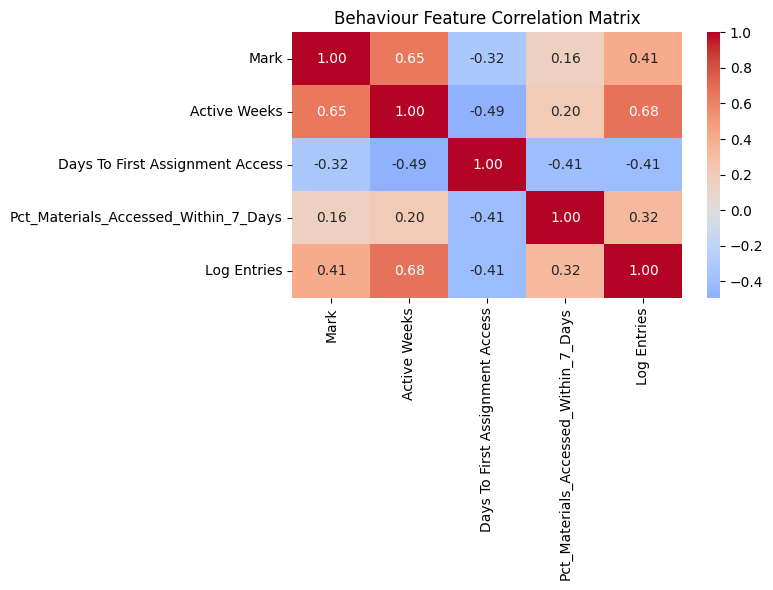

In [58]:
# heatmap of behaviour features correlation with final mark
behaviour_features = student_features[
    [
        'Mark',
        'Active Weeks',
        'Days To First Assignment Access',
        'Pct_Materials_Accessed_Within_7_Days'
    ]
].copy()

# Add Log Entries from student_level_df
if 'Person Id' not in behaviour_features.columns:
    behaviour_features['Person Id'] = student_features['Person Id']

behaviour_features = behaviour_features.merge(
    student_level_df[['Person Id', 'Log Entries']].drop_duplicates(subset=['Person Id']),
    on='Person Id',
    how='left'
)

# Ensure Person Id is available for the merge
if 'Person Id' not in behaviour_features.columns:
    behaviour_features['Person Id'] = student_features['Person Id']
    behaviour_features = behaviour_features.merge(
        student_level_df[['Person Id', 'Log Entries']],
        on='Person Id',
        how='left'
    )

behaviour_corr_matrix = behaviour_features.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    behaviour_corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Behaviour Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Finding 15: Behavioural Engagment Features Are Associated with Academic Performance
The behavioural feature correlation analysis indicates that several Moodle engagement indicators are associated with student academic performance. 

Among the behavioural features examined, Active Weeks showed the strongest positive relationship, r = 0.65. 
Log entries also demonstrated a moderate positive relationship with final marks r = 0.41. 
The timing of initial engagement exhibited negative negative relationships with final marks with r = -0.32
Days to first file Access showed a weaker negative correlation 

In [59]:
performance_corr = pd.DataFrame({
    'Feature': [
        'Weekly Quiz Score',
        'Assignment 2 Score',
        'Assignment 1 Score'
    ],
    'Correlation with Final Mark': [
        0.834,
        0.692,
        0.613
    ]
})

performance_corr['Abs Corr'] = performance_corr['Correlation with Final Mark'].abs()

performance_corr = performance_corr.sort_values(
    'Abs Corr',
    ascending=False
)

performance_corr

,Feature,Correlation with Final Mark,Abs Corr
0,Weekly Quiz Score,0.834,0.834
1,Assignment 2 Score,0.692,0.692
2,Assignment 1 Score,0.613,0.613


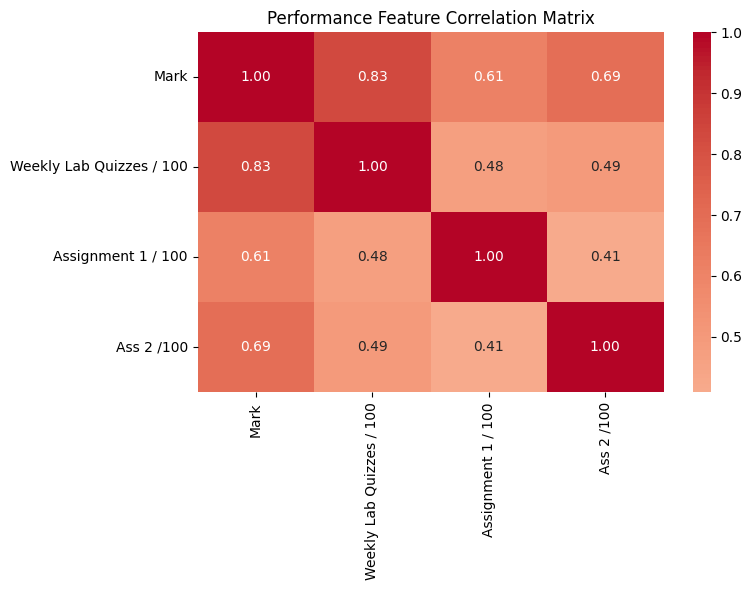

In [60]:
performance_features = results[
    [
        'Mark',
        'Weekly Lab Quizzes / 100',
        'Assignment 1 / 100',
        'Ass 2 /100'
    ]
].copy()

performance_features = performance_features.apply(
    pd.to_numeric,
    errors='coerce'
)

performance_corr_matrix = performance_features.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    performance_corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Performance Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [61]:
# create material counts per student
# Ensure Material Type column exists in data_log
if 'Material Type' not in data_log.columns:
    data_log['Material Type'] = data_log['Event context'].apply(classify_material)

student_material_counts = (
    data_log
    .groupby(['Person Id', 'Material Type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# assign weights
material_weights = {
    'Grade / Report': 1,
    'Assignment': 5,
    'Quiz': 4,
    'Recorded Session': 3,
    'Forum': 2,
    'Lecture Material': 3,
    'File': 2,
    'Course / Unit Page': 1,
    'Other': 1
}

# calculate weighted engagement score
student_material_counts['Weighted Engagement Score'] = 0

for material, weight in material_weights.items():
    if material in student_material_counts.columns:
        student_material_counts['Weighted Engagement Score'] += (
            student_material_counts[material] * weight
        )

# merge with marks
weighted_analysis = student_material_counts.merge(
    results[['Person Id', 'Mark', 'Grade']],
    on='Person Id',
    how='inner'
)

weighted_analysis['Mark'] = pd.to_numeric(
    weighted_analysis['Mark'],
    errors='coerce'
)

weighted_analysis = weighted_analysis.dropna(subset=['Mark'])

# check correlation
weighted_analysis[['Weighted Engagement Score', 'Mark']].corr()

,Weighted Engagement Score,Mark
Weighted Engagement Score,1.000000,0.414393
Mark,0.414393,1.000000


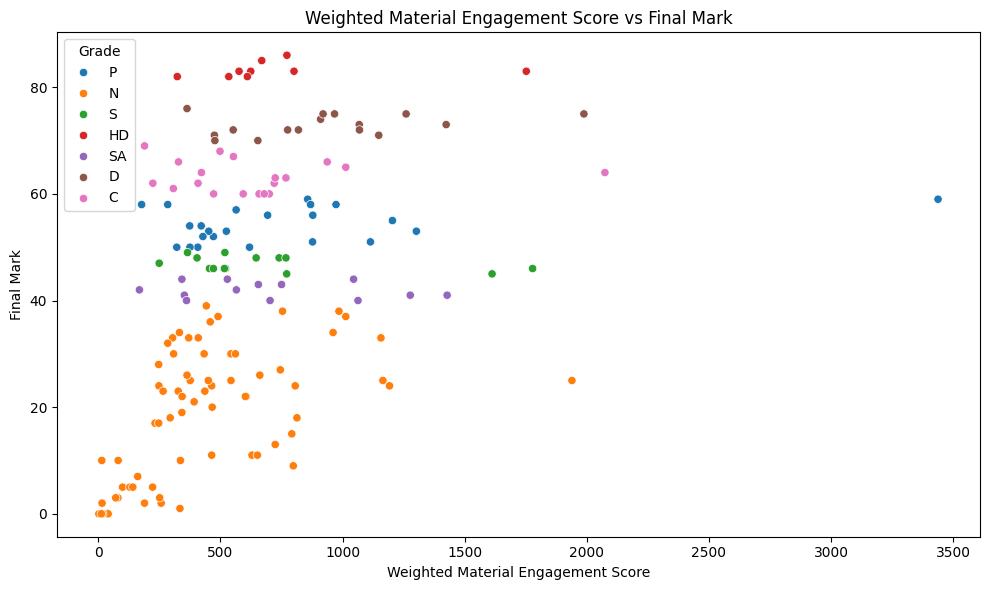

In [62]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=weighted_analysis,
    x='Weighted Engagement Score',
    y='Mark',
    hue='Grade'
)

plt.title('Weighted Material Engagement Score vs Final Mark')
plt.xlabel('Weighted Material Engagement Score')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [63]:
material_counts = (
    data_log
    .groupby(['Person Id', 'Material Type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

material_counts = material_counts.merge(
    results[['Person Id', 'Mark']],
    on='Person Id',
    how='inner'
)

corr = (
    material_counts
    .corr(numeric_only=True)['Mark']
    .drop('Mark')
    .sort_values(key=abs, ascending=False)
)

print(corr)

Assignment    0.364299
File          0.340555
Unit          0.311473
Forum         0.283856
Other         0.070480
Name: Mark, dtype: float64


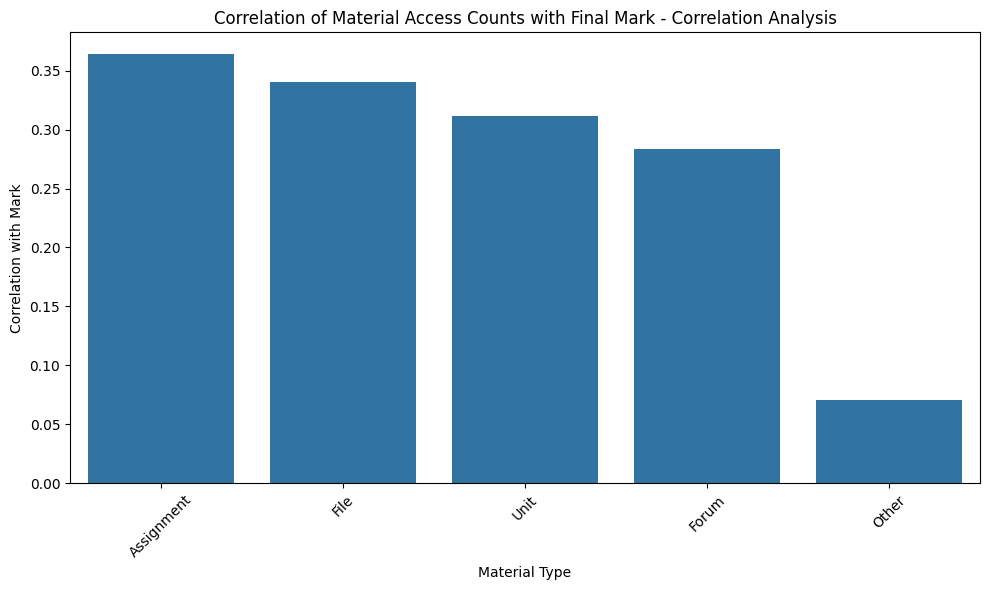

In [64]:
# plot correlation of material types with mark
plt.figure(figsize=(10, 6))
sns.barplot(
    x=corr.index,
    y=corr.values
)
plt.xticks(rotation=45)
plt.title('Correlation of Material Access Counts with Final Mark - Correlation Analysis')
plt.ylabel('Correlation with Mark')
plt.xlabel('Material Type')
plt.tight_layout()
plt.show()

## Finding 16: Material Engagement Types and Academic Performance 

Analysis of learning material interactions showed that assignment-related activities exhibited the strongest relationship with academic performance (r = 0.364). Moderate positive relationships were also observed for file access (r = 0.333), course page access (r = 0.311), lecture material access (r = 0.294), and forum participation (r = 0.284).

A Random Forest feature importance analysis further confirmed that assignment engagement was the most influential behavioural factor (importance = 0.390), followed by lecture materials (0.152), file access (0.150), and course page access (0.122). These findings suggest that different learning resources contribute unequally to student success and may be useful when constructing engagement-based risk indicators.

In [65]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = material_counts.drop(
    columns=['Person Id', 'Mark']
)

y = material_counts['Mark']

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

y = pd.to_numeric(y, errors='coerce')
valid_mask = y.notna()

X = X.loc[valid_mask]
y = y.loc[valid_mask]

rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

      Feature  Importance
0  Assignment    0.460633
1        File    0.200642
4        Unit    0.158019
2       Forum    0.122992
3       Other    0.057713


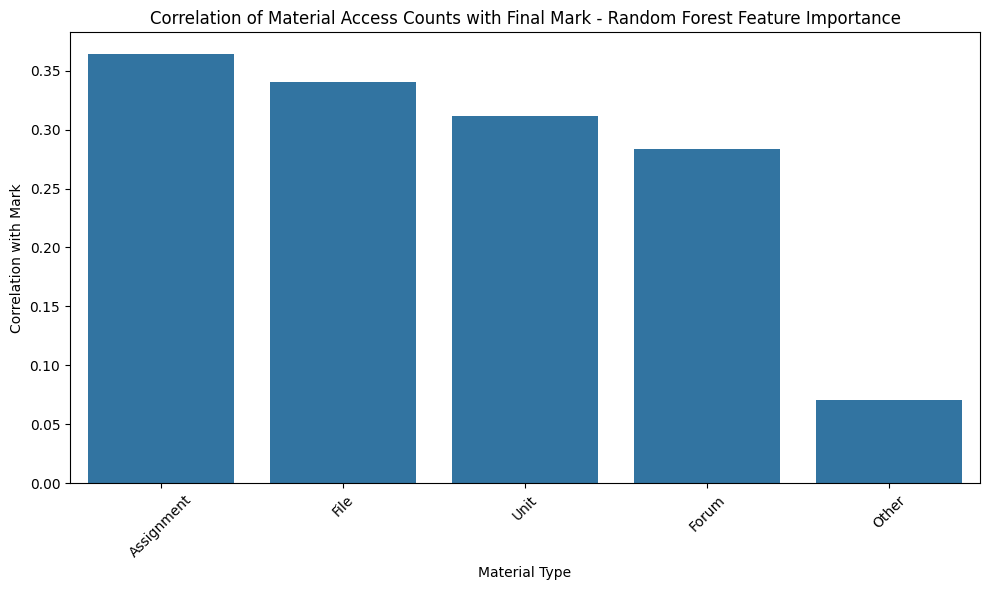

In [66]:
# plot correlation of material types with mark
plt.figure(figsize=(10, 6))
sns.barplot(
    x=corr.index,
    y=corr.values
)
plt.xticks(rotation=45)
plt.title('Correlation of Material Access Counts with Final Mark - Random Forest Feature Importance')
plt.ylabel('Correlation with Mark')
plt.xlabel('Material Type')
plt.tight_layout()
plt.show()

## Finding 17: Relative Importance of Material Types for Predicting Academic Performance

Random Forest feature importance analysis was conducted to evaluate the relative contribution of different material types to predicting students’ final marks. The results indicate that assignment-related interactions were the most influential predictor of academic performance, with a feature importance score of 0.461. This was substantially higher than all other material types, suggesting that engagement with assignments provides the strongest signal of student success.

File access was identified as the second most important predictor (0.201), followed by course/unit page access (0.158) and forum participation (0.123). These findings suggest that students who regularly engage with learning resources, navigate course content, and participate in course discussions tend to achieve better academic outcomes.

The relatively low importance of the Other category (0.058) indicates that miscellaneous activities contribute little additional predictive value compared with core learning activities.

Overall, the results suggest that assignment interactions, resource access, course navigation, and forum engagement are valuable behavioural indicators for inclusion in future student risk prediction models. Assignment-related activity appears to be particularly informative and may serve as a key feature when identifying students who may be academically at risk.


### Limitation 
It should be noted that feature importance values from Random Forest represent the relative contribution of variables within the predictive model rather than direct statistical relationships with final marks. Furthermore, assignment interactions may partly reflect assessment-related behaviour and therefore should be carefully evaluated for potential information leakage when developing early-semester prediction models. Future models should prioritise features that are available before assessment outcomes become known to ensure realistic and deployable risk predictions.

In [67]:
# Ensure required correlation series exist
if 'raw_corr' not in globals():
    raw_corr = (
        material_counts
        .corr(numeric_only=True)['Mark']
        .drop('Mark', errors='ignore')
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

if 'pct_corr' not in globals():
    material_cols = [c for c in material_counts.columns if c not in ['Person Id', 'Mark']]
    pct_df = material_counts[material_cols].div(
        material_counts[material_cols].sum(axis=1), axis=0
    ) * 100
    pct_df['Mark'] = pd.to_numeric(material_counts['Mark'], errors='coerce')

    pct_corr = (
        pct_df
        .corr(numeric_only=True)['Mark']
        .drop('Mark', errors='ignore')
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

raw_table = raw_corr.reset_index()
raw_table.columns = ['Material Type', 'Raw Count Corr']

pct_table = pct_corr.reset_index()
pct_table.columns = ['Material Type', 'Percentage Corr']

# remove % suffix
pct_table['Material Type'] = (
    pct_table['Material Type']
    .str.replace(' %', '', regex=False)
)

rf_table = importance.copy()
rf_table.columns = ['Material Type', 'RF Importance']

comparison = (
    raw_table
    .merge(pct_table, on='Material Type', how='outer')
    .merge(rf_table, on='Material Type', how='outer')
)

comparison = comparison.sort_values(
    'RF Importance',
    ascending=False
)

comparison.round(3)

,Material Type,Raw Count Corr,Percentage Corr,RF Importance
0,Assignment,0.364,0.061,0.461
1,File,0.341,0.173,0.201
4,Unit,0.311,-0.201,0.158
2,Forum,0.284,-0.034,0.123
3,Other,0.070,0.001,0.058


## Finding 18: Material Engagement Types and Academic Performance 
Analysis was conducted using both raw access counts and proportional access percentages to understand how different learning materials relate to academic performance. 

The raw count analysis showed that assignment access exhibited the strongest positive relationship with final marks (r= 0.364), followed by file access (r = 0.333), course/unit page access (r = 0.311), lecture materials (r = 0.294), and forum participation (r = 0.284). These results suggest that higher-performing students generally interact more frequently with learning resources throughout the semester. 

However, when access patterns were normalized as percentage of each student's total activity, different trends emerged. Lecture material access showed a positive relationship with final marks (r=0.170), while course/unit page access demonstrated a negative relationship (r = -0.201). This indicates that although successful students perform more activities overall, they also tend to allocate a greater proportion of their engagement toward learning resources rather than navigation pages. 

These findings suggest that the type of engagement may be as important as the volume of engagement. Students who focus more heavily on lecture materials, files, and assignments appearto achieve better academic outcomes, whereas students whose activity is concentrated on course navigation pages may not be engaging as deeply with learning content. 

The comparison between raw counts and percentages highlights the importance of considering both engagement volume and distribution when developing predictive models for identifying academically at-risk students. 

In [68]:
# raw count correlation
raw_corr = (
    material_counts
    .corr(numeric_only=True)['Mark']
    .drop('Mark')
    .sort_values(key=abs, ascending=False)
)

# print(raw_corr)

# percentage correlation
material_pct = material_counts.copy()

material_cols = [
    col for col in material_counts.columns
    if col not in ['Person Id', 'Mark']
]

material_pct['Total Accesses'] = material_pct[material_cols].sum(axis=1)

for col in material_cols:
    material_pct[col + ' %'] = (
        material_pct[col]
        / material_pct['Total Accesses']
        * 100
    )

pct_cols = [col + ' %' for col in material_cols]

pct_corr = (
    material_pct[pct_cols + ['Mark']]
    .corr(numeric_only=True)['Mark']
    .drop('Mark')
    .sort_values(key=abs, ascending=False)
)

# print(pct_corr)

#  comparison table
raw_table = raw_corr.reset_index()
raw_table.columns = ['Material Type', 'Raw Count Corr']

pct_table = pct_corr.reset_index()
pct_table.columns = ['Material Type', 'Percentage Corr']

pct_table['Material Type'] = (
    pct_table['Material Type']
    .str.replace(' %', '', regex=False)
)

comparison = (
    raw_table
    .merge(
        pct_table,
        on='Material Type',
        how='outer'
    )
)

comparison['Abs Raw'] = comparison['Raw Count Corr'].abs()
comparison['Abs Pct'] = comparison['Percentage Corr'].abs()

comparison = comparison.sort_values(
    'Abs Raw',
    ascending=False
)

comparison.round(3)

,Material Type,Raw Count Corr,Percentage Corr,Abs Raw,Abs Pct
0,Assignment,0.364,0.061,0.364,0.061
1,File,0.341,0.173,0.341,0.173
4,Unit,0.311,-0.201,0.311,0.201
2,Forum,0.284,-0.034,0.284,0.034
3,Other,0.070,0.001,0.070,0.001


## Finding 19: Feature Importance Analysis 
Random Forest feature importance analysis further supported the correlation findings. Assignment interactions were identified as the most influential material type (importance = 0.390), followed by lecture materials (0.152), and course/unit pages (0.122). 

Unlike pearson analysis, RF evalutes the combined predictive contribution of all variables simultaneously. The results suggest that assignment engagment provides the strongest signal for predicting student performance, while lecture materials and file access also contribute meaningful predictive information. 

These findings indicate that material engagement features may be useful behavioral indicators for future student performance prediction models and could be incorporated into an early warning system for identifying students at risk of poor academic outcomes. 